In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [5]:
accu_df = pd.read_csv("Datasets\synthetic_accural_data.csv") 

accu_df["transaction_date"] = pd.to_datetime(accu_df["transaction_date"])

print("Shape:", accu_df.shape)
accu_df.head()

Shape: (8219, 39)


,transaction_id,customer_unique_id,transaction_date,transaction_type,points,partner_id,store_id,opening_balance,closing_balance,amount,...,trans_currency,conversion_rate,amount_in_trans_currency,usd_conversion_rate,amount_in_usd,channel_code,point_expiry,funding_partner_id,point_type_id,calculated_amount
0,TXN00002862,0006417714fe4a78913920f39a03cdf7,2023-01-06 07:30:00,earn,333.09,439,3896,0.00,333.09,2307.33,...,USD,0.6737,1554.45,0.0805,185.74,CPN,2023-06-05 07:30:00.000000,439,9,2217.93
1,TXN00002863,0006417714fe4a78913920f39a03cdf7,2023-01-08 06:19:00,earn,314.54,439,3025,333.09,647.63,4863.34,...,INR,0.9181,4465.03,0.0969,471.26,CPN,2024-11-02 06:19:00.000000,439,13,4883.89
2,TXN00002864,0006417714fe4a78913920f39a03cdf7,2023-01-09 10:06:00,earn,341.69,212,4950,647.63,989.32,644.58,...,SGD,0.6280,404.80,0.0687,44.28,POS,2023-12-29 10:06:00.000000,212,19,604.63
3,TXN00002866,0006417714fe4a78913920f39a03cdf7,2023-01-11 08:48:00,earn,274.21,439,1144,660.26,934.47,3202.35,...,AED,1.1400,3650.68,0.0767,245.62,POS,2024-10-30 08:48:00.000000,439,15,3627.60
4,TXN00002868,0006417714fe4a78913920f39a03cdf7,2023-01-13 08:15:00,earn,350.79,439,1145,885.07,1235.86,4056.82,...,AED,1.2190,4945.26,0.0618,250.71,CPN,2023-12-27 08:15:00.000000,439,3,4557.73


In [8]:
accu_df.info()
accu_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8219 entries, 0 to 8218
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   transaction_id            8219 non-null   str           
 1   customer_unique_id        8219 non-null   str           
 2   transaction_date          8219 non-null   datetime64[us]
 3   transaction_type          8219 non-null   str           
 4   points                    8219 non-null   float64       
 5   partner_id                8219 non-null   int64         
 6   store_id                  8219 non-null   int64         
 7   opening_balance           8219 non-null   float64       
 8   closing_balance           8219 non-null   float64       
 9   amount                    8219 non-null   float64       
 10  is_anomaly                8219 non-null   int64         
 11  anomaly_types             1578 non-null   str           
 12  country_code              8219 

,transaction_date,points,partner_id,store_id,opening_balance,closing_balance,amount,is_anomaly,country_code,activity_id,...,rule_id,program_id,program_country,conversion_rate,amount_in_trans_currency,usd_conversion_rate,amount_in_usd,funding_partner_id,point_type_id,calculated_amount
count,8219,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,...,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000,8219.000000
mean,2023-01-25 14:36:42.259875,167.517385,352.414649,2983.577686,419.938345,587.455731,2486.573685,0.191994,286.177759,248.513688,...,25.013505,14.959606,278.648619,1.258769,3126.510197,0.055305,138.206361,352.414649,10.002312,2484.855767
min,2023-01-01 07:08:00,22.520000,200.000000,1000.000000,0.000000,22.570000,10.070000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.500100,5.430000,0.010000,0.190000,200.000000,1.000000,8.600000
25%,2023-01-10 15:02:30,85.865000,282.000000,1986.500000,39.535000,172.500000,1251.730000,0.000000,65.000000,127.000000,...,13.000000,8.000000,1.000000,0.885400,1353.955000,0.032500,47.720000,282.000000,5.000000,1245.290000
50%,2023-01-16 19:33:00,145.630000,353.000000,2971.000000,233.840000,386.120000,2487.370000,0.000000,91.000000,249.000000,...,25.000000,15.000000,65.000000,1.265200,2728.100000,0.055400,110.970000,353.000000,10.000000,2459.460000
75%,2023-01-31 16:37:00,238.225000,426.000000,3978.000000,614.885000,839.510000,3711.800000,0.000000,971.000000,370.000000,...,37.000000,22.000000,91.000000,1.630700,4564.020000,0.078300,205.405000,426.000000,15.000000,3658.710000
max,2025-01-12 20:14:00,1865.490000,500.000000,4999.000000,3578.830000,3861.580000,4999.910000,1.000000,971.000000,499.000000,...,49.000000,29.000000,971.000000,1.999800,9887.610000,0.100000,484.700000,500.000000,19.000000,5986.750000
std,NaN,119.882785,85.353800,1150.024482,512.888295,566.161027,1428.230360,0.393892,401.380351,142.574924,...,14.176303,8.423236,397.509090,0.434202,2171.029069,0.026162,109.436493,85.353800,5.440568,1464.595504


In [9]:
missing = accu_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print(missing)

anomaly_types    6641
dtype: int64


In [10]:
accu_df["is_anomaly"].value_counts(normalize=True)

is_anomaly
0    0.808006
1    0.191994
Name: proportion, dtype: float64

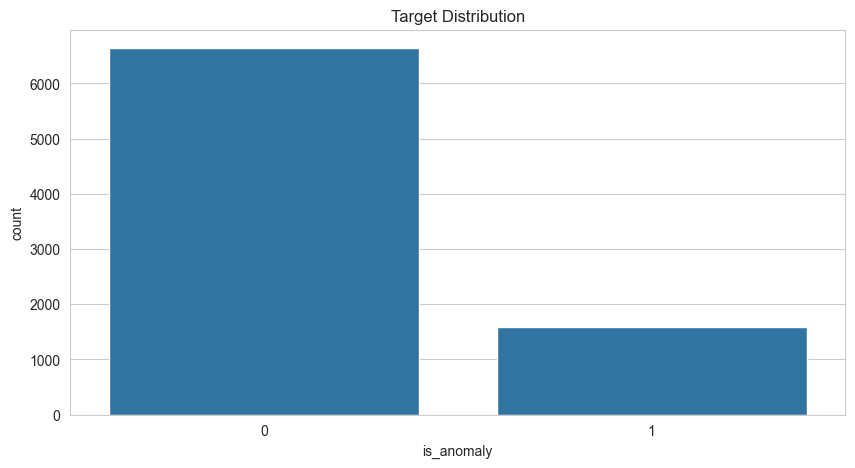

In [11]:
sns.countplot(x="is_anomaly", data=accu_df)
plt.title("Target Distribution")
plt.show()

In [12]:
user_fraud_rate = accu_df.groupby("customer_unique_id")["is_anomaly"].mean()

user_fraud_rate.describe()

count    1741.000000
mean        0.120420
std         0.237192
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: is_anomaly, dtype: float64

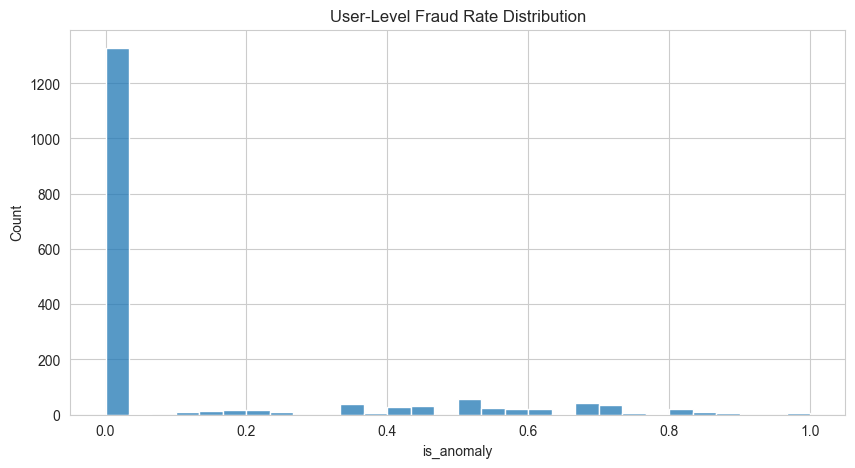

In [13]:
sns.histplot(user_fraud_rate, bins=30)
plt.title("User-Level Fraud Rate Distribution")
plt.show()

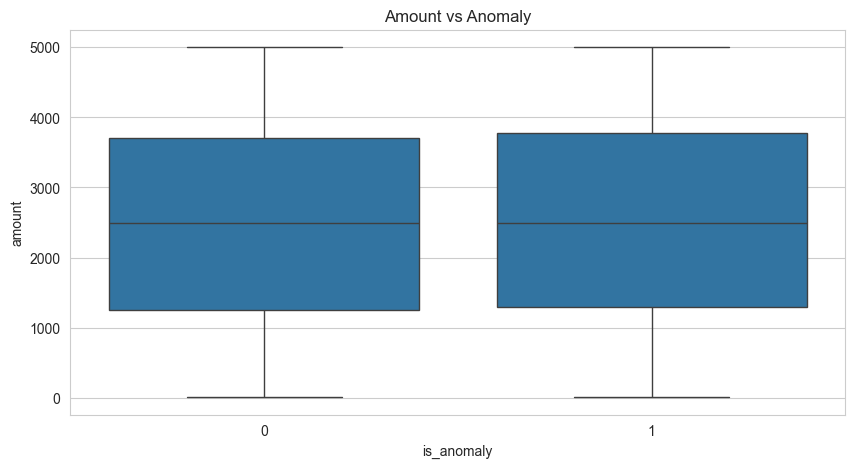

In [14]:
sns.boxplot(x="is_anomaly", y="amount", data=accu_df)
plt.title("Amount vs Anomaly")
plt.show()

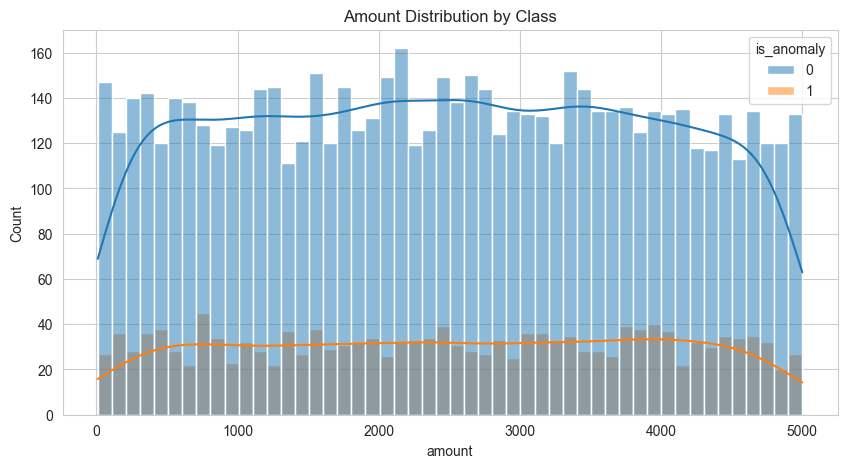

In [15]:
sns.histplot(data=accu_df, x="amount", hue="is_anomaly", bins=50, kde=True)
plt.title("Amount Distribution by Class")
plt.show()

In [70]:
accu_df["hour"] = accu_df["transaction_date"].dt.hour
accu_df["day_of_week"] = accu_df["transaction_date"].dt.dayofweek
accu_df["is_weekend"] = accu_df["day_of_week"].isin([5, 6]).astype(int)

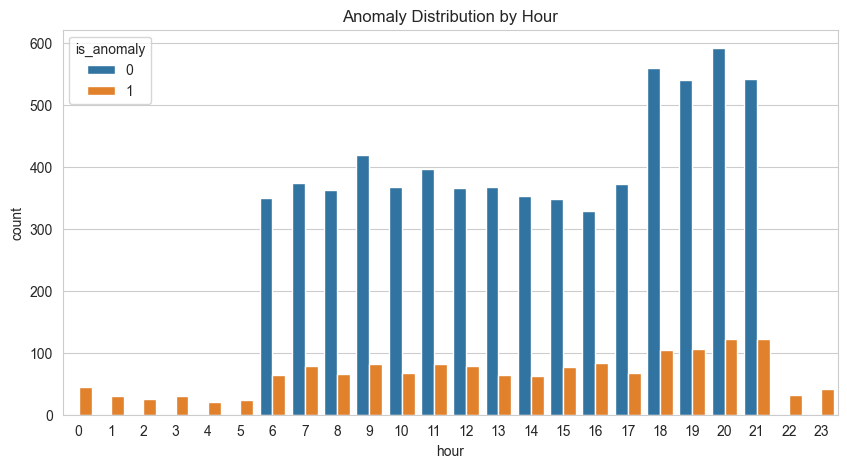

In [71]:
sns.countplot(x="hour", hue="is_anomaly", data=accu_df)
plt.title("Anomaly Distribution by Hour")
plt.show()

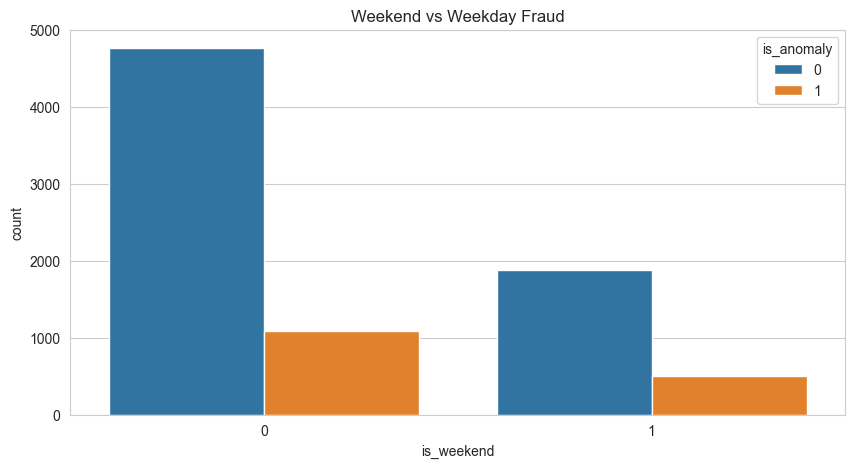

In [72]:
sns.countplot(x="is_weekend", hue="is_anomaly", data=accu_df)
plt.title("Weekend vs Weekday Fraud")
plt.show()

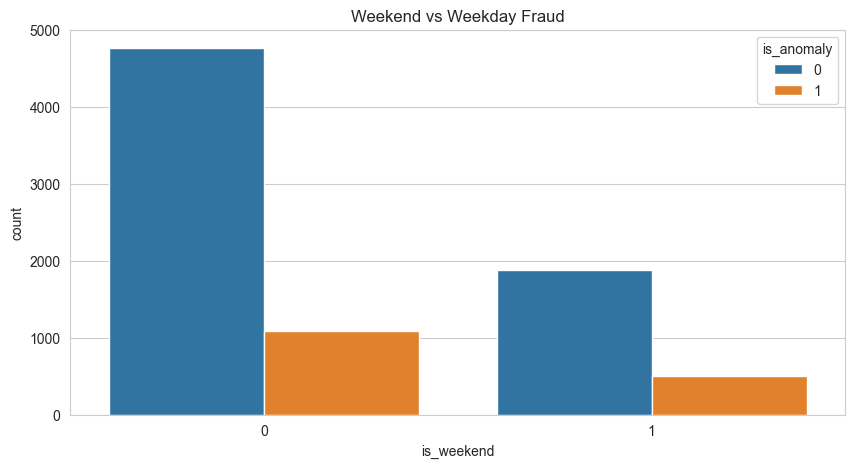

In [73]:
sns.countplot(x="is_weekend", hue="is_anomaly", data=accu_df)
plt.title("Weekend vs Weekday Fraud")
plt.show()

In [74]:
accu_df = accu_df.sort_values(["customer_unique_id", "transaction_date"])

In [75]:
accu_df["prev_time"] = accu_df.groupby("customer_unique_id")["transaction_date"].shift(1)
accu_df["time_gap_sec"] = (accu_df["transaction_date"] - accu_df["prev_time"]).dt.total_seconds()

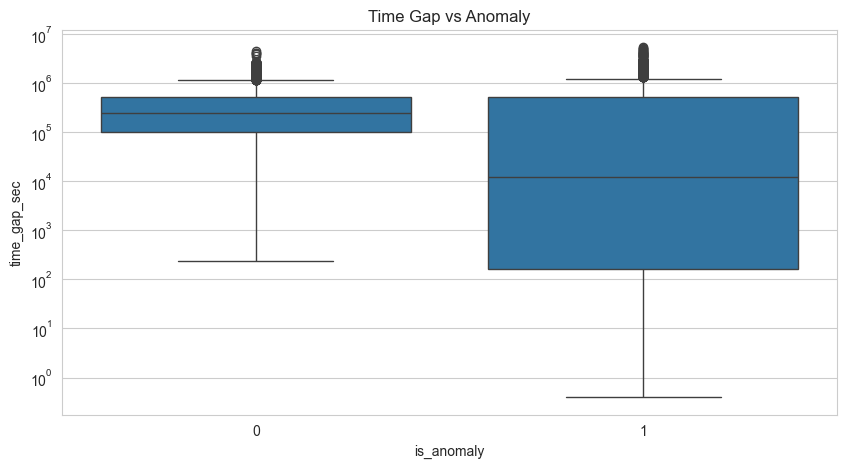

In [24]:
sns.boxplot(x="is_anomaly", y="time_gap_sec", data=accu_df)
plt.title("Time Gap vs Anomaly")
plt.yscale("log")
plt.show()

In [30]:
accu_df["balance_depletion_ratio"] = accu_df["points"] / (accu_df["opening_balance"] + 1e-6)

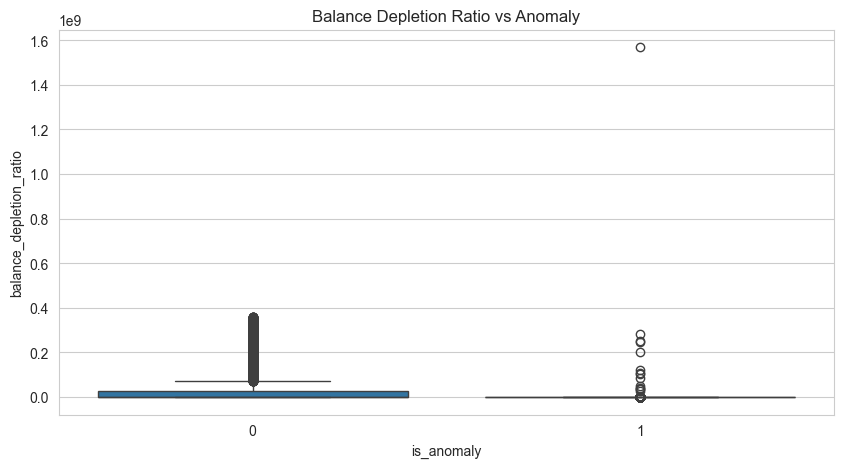

In [31]:
sns.boxplot(x="is_anomaly", y="balance_depletion_ratio", data=accu_df)
plt.title("Balance Depletion Ratio vs Anomaly")
plt.show()

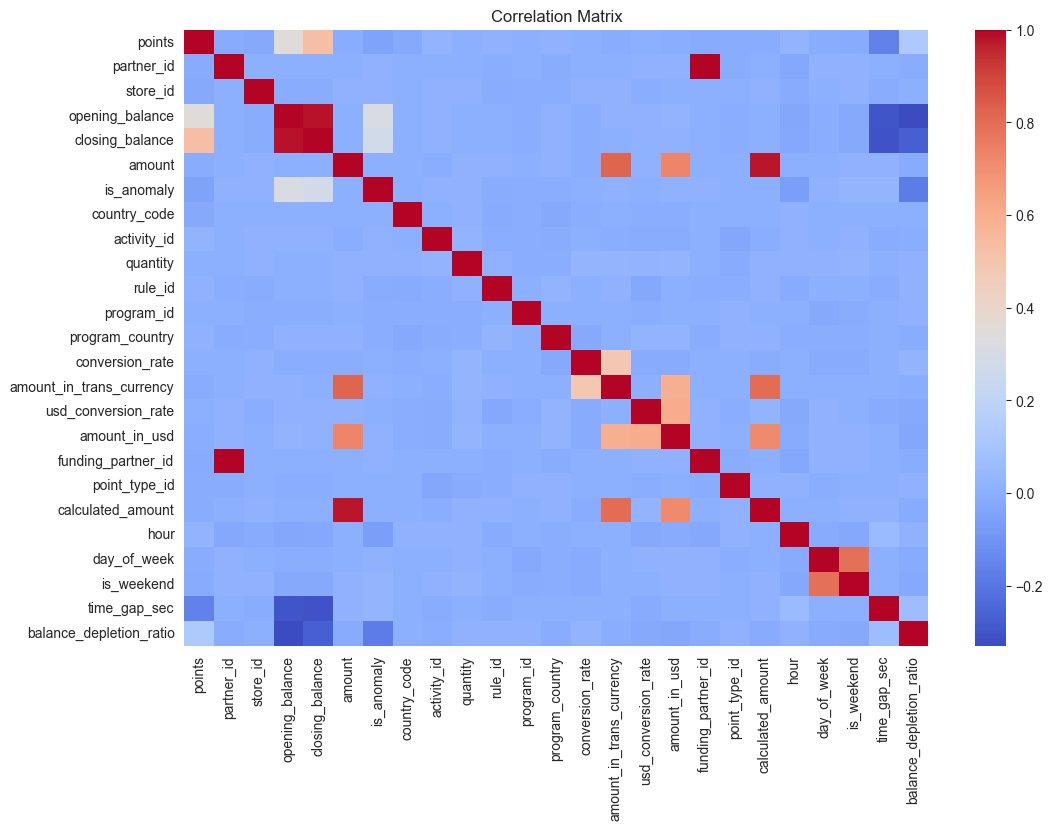

In [32]:
numeric_cols = accu_df.select_dtypes(include=[np.number]).columns

corr = accu_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [76]:
target_corr = corr["is_anomaly"].abs().sort_values(ascending=False)
target_corr

is_anomaly                     1.000000
transactions_last_24h          0.317537
opening_balance                0.314204
closing_balance                0.275034
transactions_last_5_min        0.263856
transactions_last_10_min       0.225018
transactions_last_1h           0.223472
time_since_last_transaction    0.099562
hour                           0.063433
points                         0.045365
amount_to_user_avg_ratio       0.031822
is_weekend                     0.027941
time_gap_sec                   0.026236
funding_partner_id             0.018009
partner_id                     0.018009
day_of_week                    0.017772
activity_id                    0.015628
store_id                       0.013315
amount_in_usd                  0.012625
amount_in_trans_currency       0.011069
quantity                       0.010194
user_avg_amount                0.010095
country_code                   0.007995
point_type_id                  0.007969
rule_id                        0.007656


In [6]:
def add_behavioral_features(df):
    
    df = df.copy()
    
    # Ensure sorted
    df = df.sort_values(
        by=["customer_unique_id", "transaction_date"]
    )
    
    # time_since_last_transaction
    df["prev_transaction_time"] = (
        df.groupby("customer_unique_id")["transaction_date"]
        .shift(1)
    )
    
    df["time_since_last_transaction"] = (
        df["transaction_date"] - df["prev_transaction_time"]
    ).dt.total_seconds()
    
    
    # transactions_last_1h
    df = df.set_index("transaction_date")
    

    # 10 minute window
    df["transactions_last_10_min"] = (
        df.groupby("customer_unique_id")
          .rolling("10min")["amount"]
          .count()
          .shift(1)
          .values
    )
    
    df["transactions_last_1h"] = (
        df.groupby("customer_unique_id")["customer_unique_id"]
        .rolling("1h")
        .count()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    
    
    # transactions_last_24h
    df["transactions_last_24h"] = (
        df.groupby("customer_unique_id")["customer_unique_id"]
        .rolling("24h")
        .count()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    
    df = df.reset_index()
    
    
    # user_avg_amount (expanding mean)
    df["user_avg_amount"] = (
        df.groupby("customer_unique_id")["amount"]
        .expanding()
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    
    
    # amount_to_user_avg_ratio
    df["amount_to_user_avg_ratio"] = (
        df["amount"] / df["user_avg_amount"]
    )
    
    
    # # z_score_amount
    df["user_std_amount"] = (
        df.groupby("customer_unique_id")["amount"]
        .expanding()
        .std()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    
    # df["z_score_amount"] = (
    #     (df["amount"] - df["user_avg_amount"]) /
    #     df["user_std_amount"]
    # )
    
    
    # balance_depletion_ratio
    df["balance_depletion_ratio"] = (
        df["points"] / df["opening_balance"]
    )
    
    
    # Cleanups    
    df["time_since_last_transaction"] = df["time_since_last_transaction"].fillna(-1)
    df["transactions_last_1h"] = df["transactions_last_1h"].fillna(0)
    df["transactions_last_24h"] = df["transactions_last_24h"].fillna(0)
    df["user_avg_amount"] = df["user_avg_amount"].fillna(0)
    df["user_std_amount"] = df["user_std_amount"].fillna(0)
    df["amount_to_user_avg_ratio"] = df["amount_to_user_avg_ratio"].replace([np.inf, -np.inf], 0).fillna(0)
    # df["z_score_amount"] = df["z_score_amount"].replace([np.inf, -np.inf], 0).fillna(0)
    df["balance_depletion_ratio"] = df["balance_depletion_ratio"].replace([np.inf, -np.inf], 0).fillna(0)
    
    # Optional: drop helper columns
    df = df.drop(columns=["prev_transaction_time", "user_std_amount"], errors="ignore")
    
    return df

In [7]:
accu_df = add_behavioral_features(accu_df)

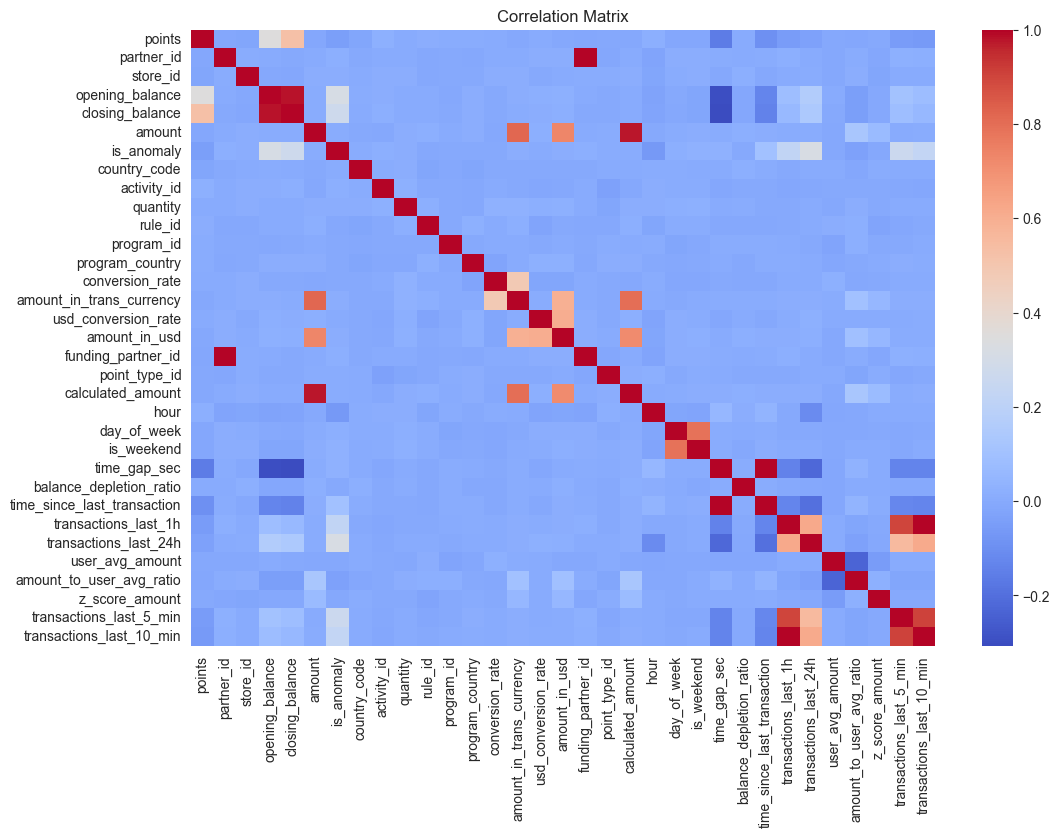

In [65]:
numeric_cols = accu_df.select_dtypes(include=[np.number]).columns

corr = accu_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [38]:
target_corr = corr["is_anomaly"].abs().sort_values(ascending=False)
target_corr

is_anomaly                     1.000000
transactions_last_24h          0.317537
opening_balance                0.314204
closing_balance                0.275034
transactions_last_1h           0.223472
time_since_last_transaction    0.099562
hour                           0.063433
points                         0.045365
amount_to_user_avg_ratio       0.031822
is_weekend                     0.027941
time_gap_sec                   0.026236
funding_partner_id             0.018009
partner_id                     0.018009
day_of_week                    0.017772
activity_id                    0.015628
store_id                       0.013315
amount_in_usd                  0.012625
amount_in_trans_currency       0.011069
quantity                       0.010194
user_avg_amount                0.010095
country_code                   0.007995
point_type_id                  0.007969
rule_id                        0.007656
calculated_amount              0.006574
z_score_amount                 0.006564


In [59]:
behavioral_cols = [
    "time_since_last_transaction",
    "transactions_last_1h",
    "transactions_last_24h",
    "user_avg_amount",
    "user_std_amount",
    "amount_to_user_avg_ratio",
    "z_score_amount",
    "balance_depletion_ratio"
]


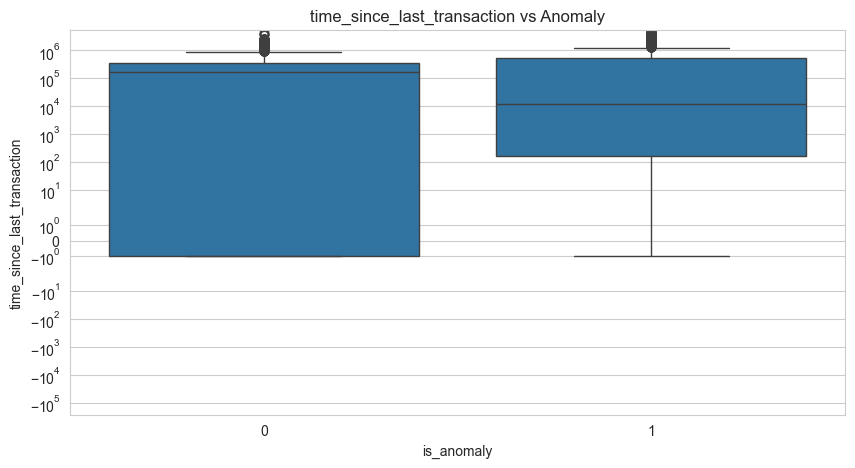

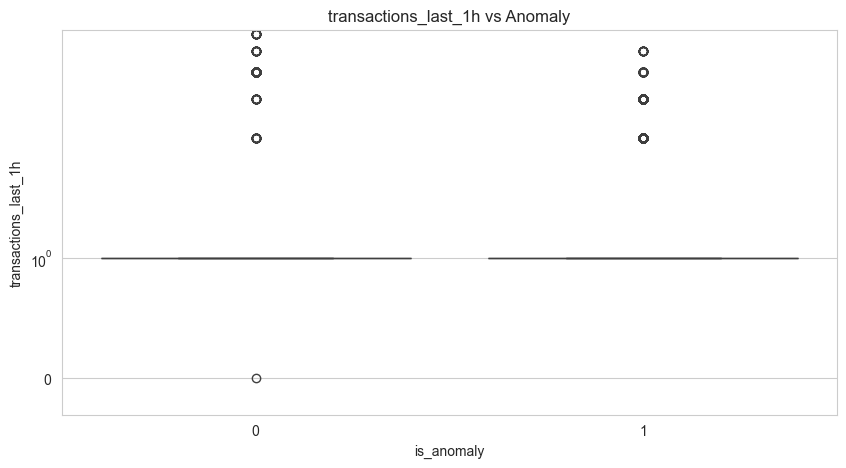

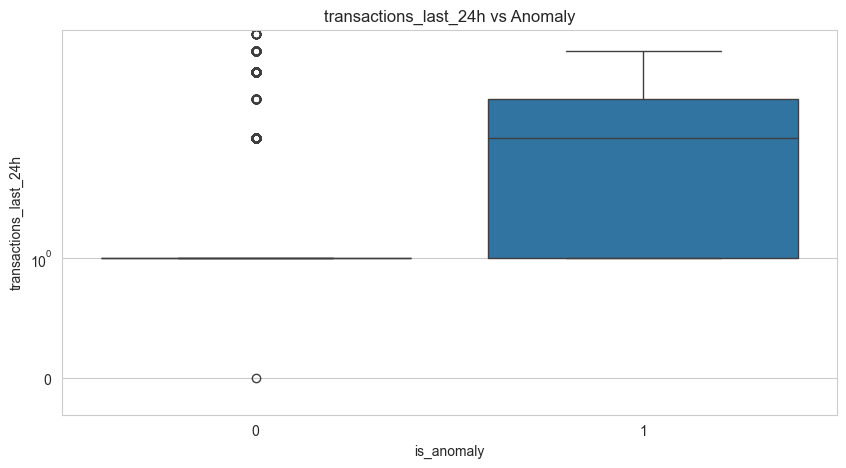

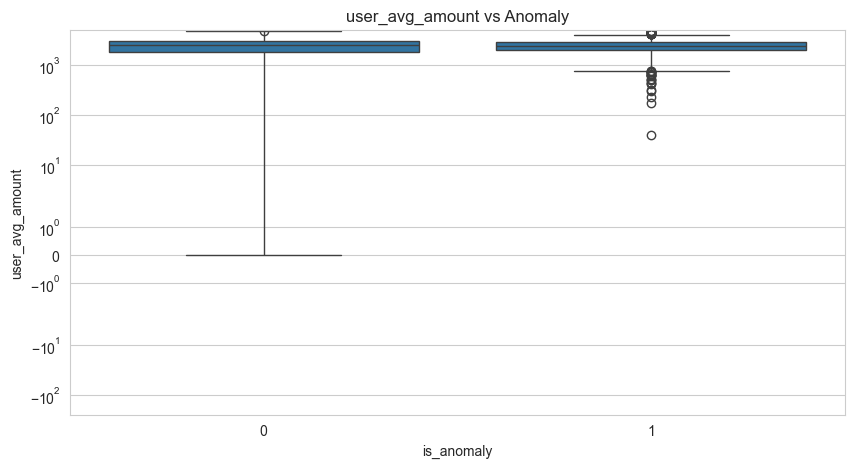

ValueError: Could not interpret value `user_std_amount` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

In [60]:
for col in behavioral_cols:
    plt.figure()
    sns.boxplot(x="is_anomaly", y=col, data=accu_df)
    plt.title(f"{col} vs Anomaly")
    plt.yscale("symlog")  # handles skewed distributions
    plt.show()

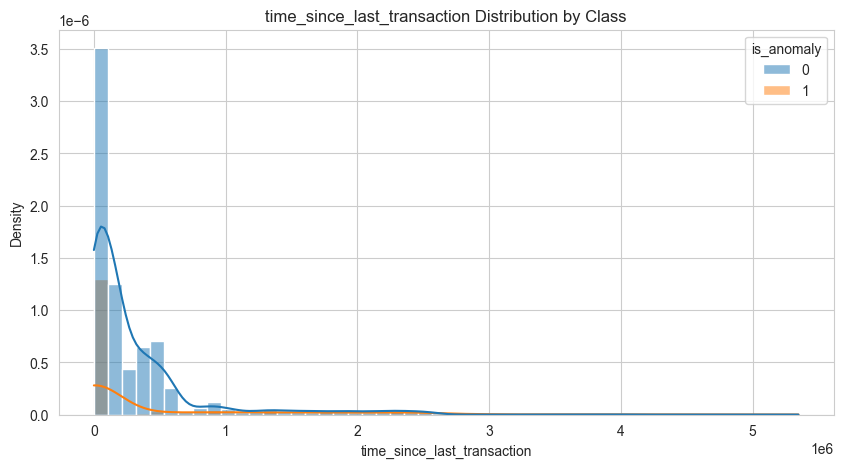

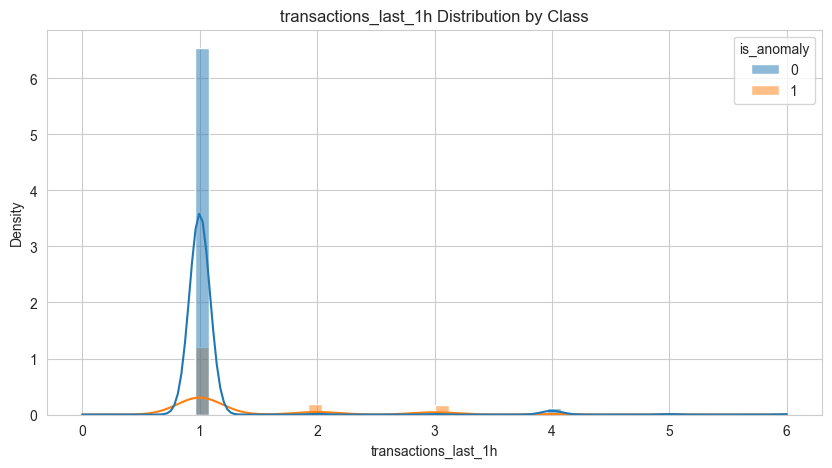

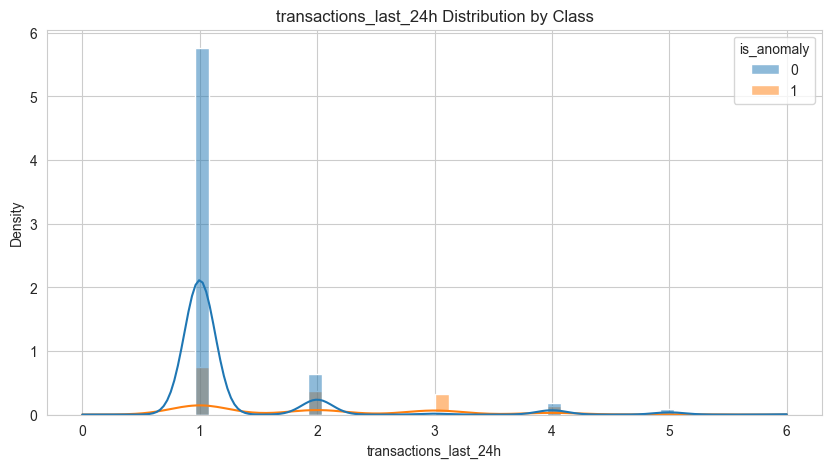

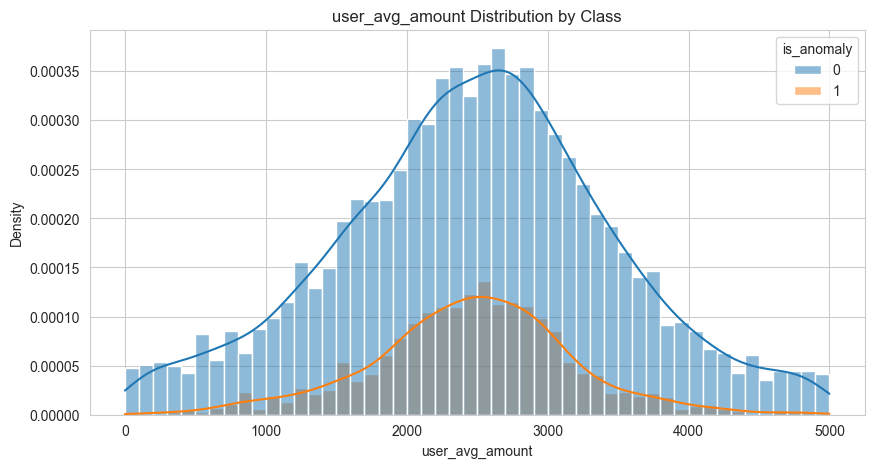

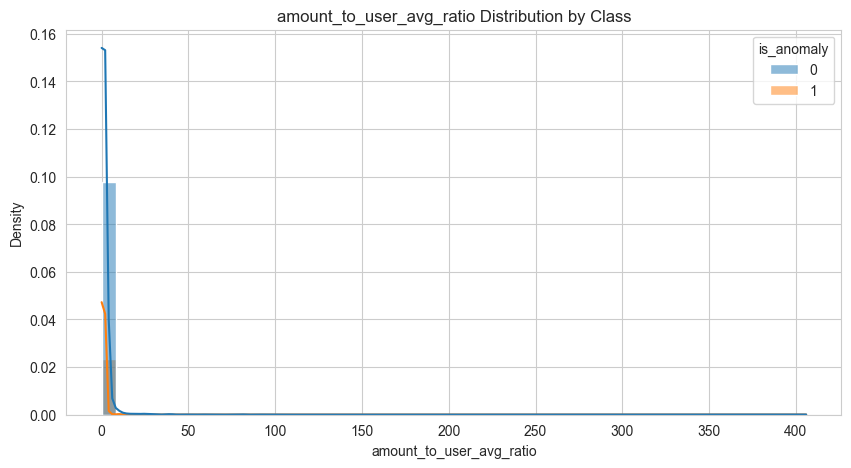

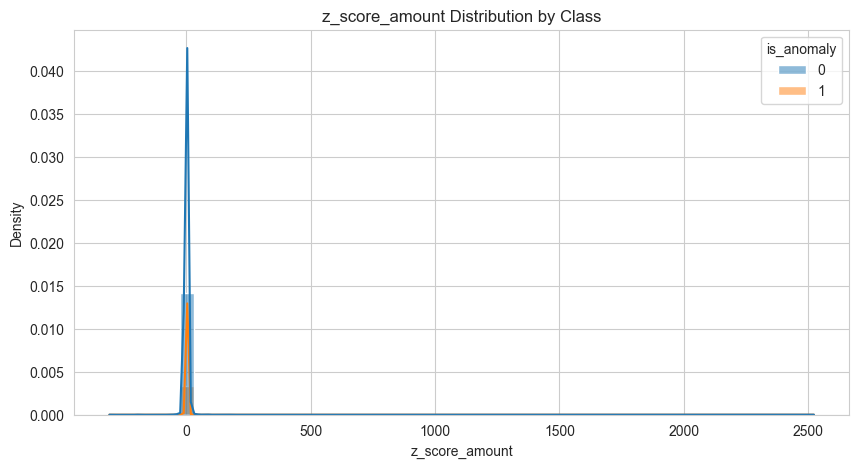

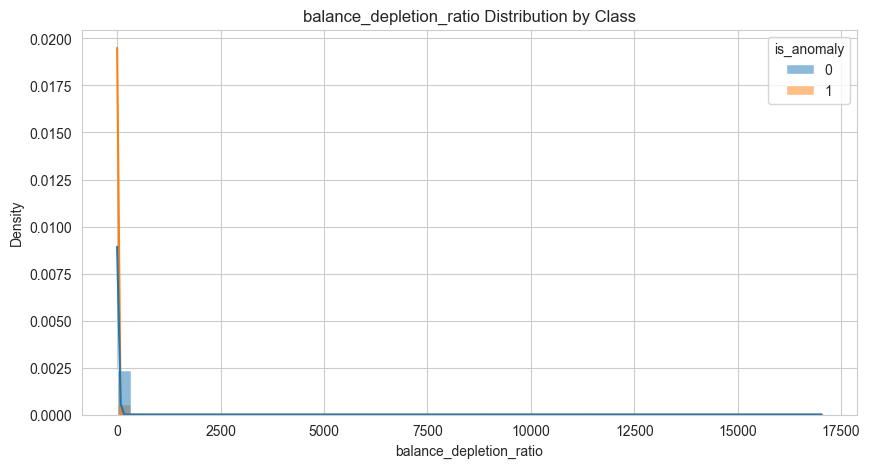

In [ ]:
for col in behavioral_cols:
    plt.figure()
    sns.histplot(data=accu_df, x=col, hue="is_anomaly", bins=50, kde=True, stat="density")
    plt.title(f"{col} Distribution by Class")
    plt.show()

In [61]:
accu_df.groupby("is_anomaly")[behavioral_cols].describe().T

KeyError: "Columns not found: 'user_std_amount'"

In [62]:
corr = accu_df[behavioral_cols + ["is_anomaly"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Behavioral Feature Correlation")
plt.show()

KeyError: "['user_std_amount'] not in index"

In [46]:
target_corr = corr["is_anomaly"].abs().sort_values(ascending=False)
target_corr

is_anomaly                     1.000000
transactions_last_24h          0.317537
transactions_last_1h           0.223472
time_since_last_transaction    0.099562
amount_to_user_avg_ratio       0.031822
user_avg_amount                0.010095
z_score_amount                 0.006564
balance_depletion_ratio        0.005158
Name: is_anomaly, dtype: float64

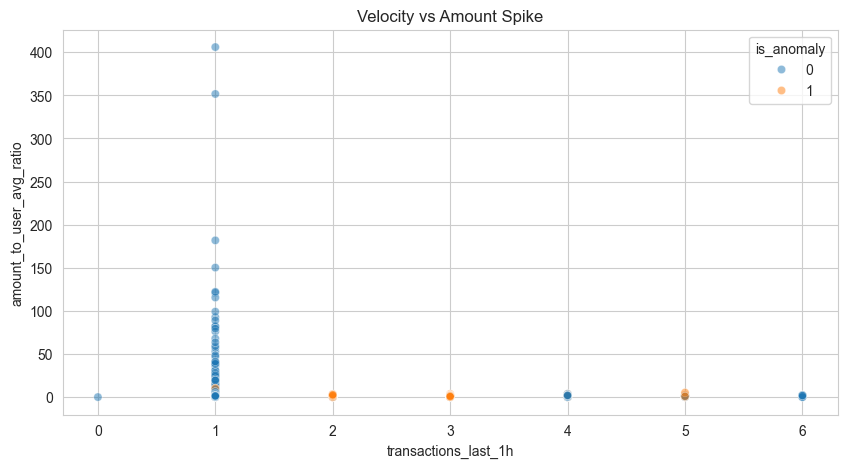

In [47]:
sns.scatterplot(
    x="transactions_last_1h",
    y="amount_to_user_avg_ratio",
    hue="is_anomaly",
    data=accu_df,
    alpha=0.5
)
plt.title("Velocity vs Amount Spike")
plt.show()

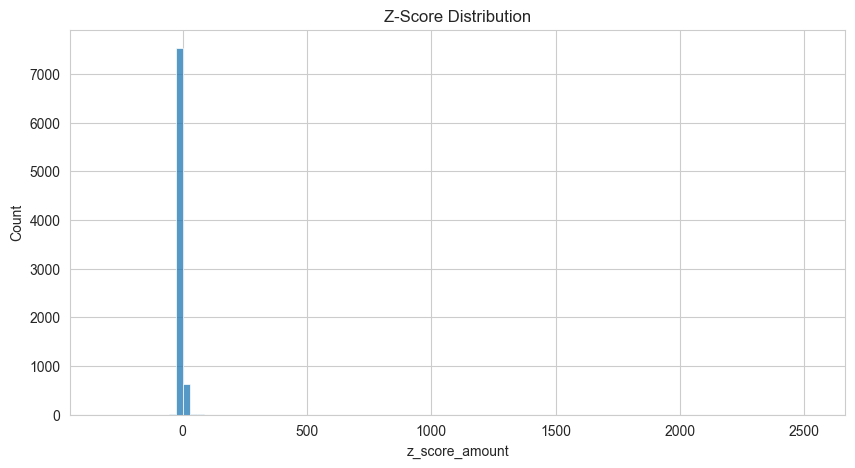

In [49]:
sns.histplot(accu_df["z_score_amount"], bins=100)
plt.title("Z-Score Distribution")
plt.show()

In [51]:
accu_df["is_first_txn"] = accu_df["time_since_last_transaction"] == -1

accu_df.groupby(["is_first_txn", "is_anomaly"]).size().unstack()

is_anomaly,0,1
is_first_txn,,
False,4904,1574
True,1737,4


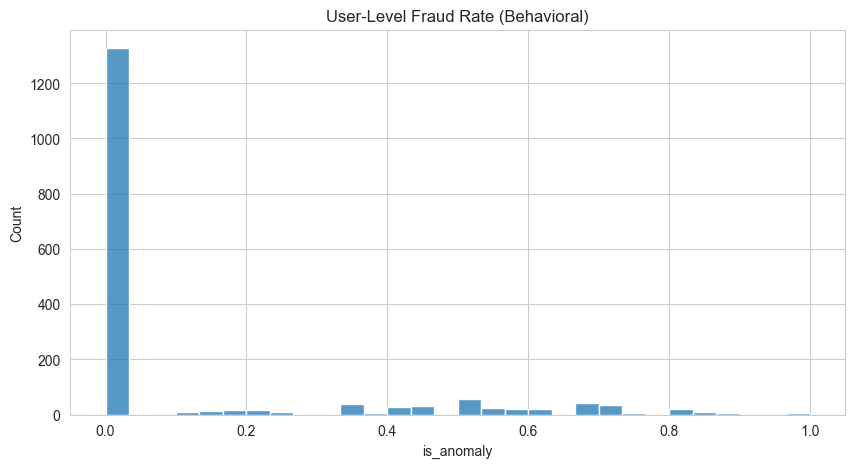

In [52]:
user_behavior = accu_df.groupby("customer_unique_id")["is_anomaly"].mean()

sns.histplot(user_behavior, bins=30)
plt.title("User-Level Fraud Rate (Behavioral)")
plt.show()

In [54]:
accu_df.groupby("is_anomaly")[behavioral_cols].mean()

,time_since_last_transaction,transactions_last_1h,transactions_last_24h,user_avg_amount,amount_to_user_avg_ratio,z_score_amount,balance_depletion_ratio
is_anomaly,,,,,,,
0,307924.319078,1.082367,1.255233,2484.828276,1.805511,0.838755,3.609370
1,453727.829817,1.422053,1.960076,2460.648878,1.177436,0.290161,1.146661


In [56]:
accu_df.groupby("is_anomaly")[behavioral_cols].median()

,time_since_last_transaction,transactions_last_1h,transactions_last_24h,user_avg_amount,amount_to_user_avg_ratio,z_score_amount,balance_depletion_ratio
is_anomaly,,,,,,,
0,166260.0,1.0,1.0,2514.3975,1.008647,0.0,0.341978
1,11790.0,1.0,2.0,2489.4000,1.009356,0.0,0.216162


<Axes: xlabel='is_anomaly', ylabel='transactions_last_24h'>

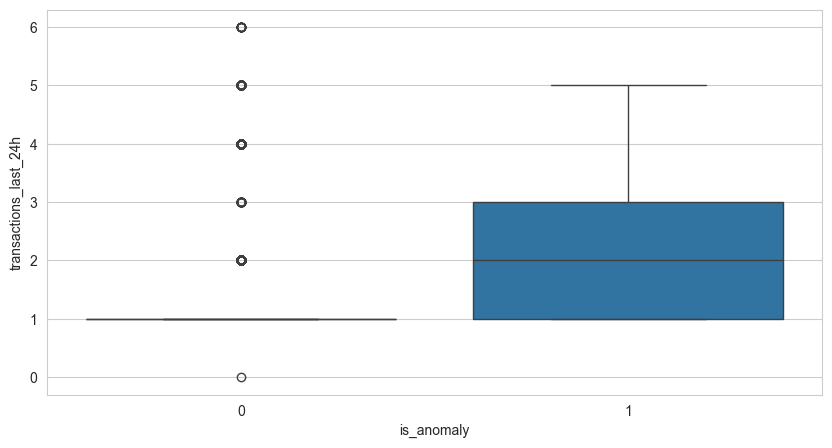

In [57]:
sns.boxplot(x="is_anomaly", y="transactions_last_24h", data=accu_df)

In [1]:
behavioral_cols = [
    "time_since_last_transaction",
    "transactions_last_10_min",
    "transactions_last_1h",
    "transactions_last_24h",
    "user_avg_amount",
    "amount_to_user_avg_ratio",
    "balance_depletion_ratio"
]

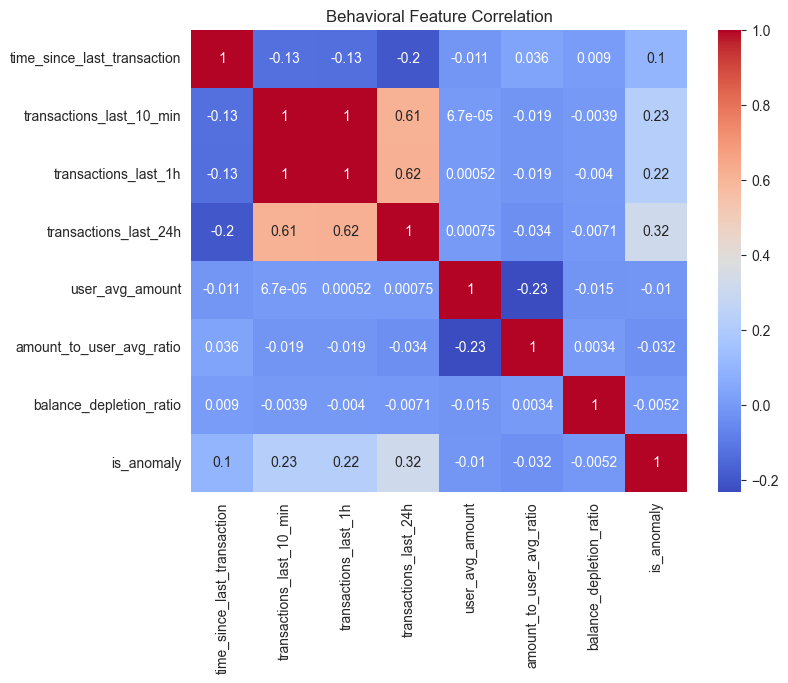

In [11]:
corr = accu_df[behavioral_cols + ["is_anomaly"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Behavioral Feature Correlation")
plt.show()